In [5]:
import pickle as pkl
import h5py as hp
%matplotlib inline
import matplotlib.pyplot as plt
import pickle as pkl
import matplotlib as mpl
import numpy as np
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'serif'

ZOOMK = [0.03, 1.0]
BIGK = [0.03, 3]
CMAP = 'plasma'
NLEVS = 75
PSIZE = 4

In [6]:
def get_2dpk(box, snap, fieldname, space = 'redshift', **others):
    path = '/home/cosinga/scratch/hcolor/output/fiducial_tng%03dB_%03dS_0A_800R/results/'%(box, snap)
    flpath = '%sgrid_tng%03dB_%03dS_0A_800R.pkl_rlib.pkl'%(fieldname, box, snap)
    rcs = pkl.load(open(path + flpath, 'rb'))
    others['space'] = space
    for rc in rcs.results['2Dpk']:
        found = []
        for k, v in others.items():
            found.append(rc.props[k] == v)
        all_found = True
        for af in found:
            if not af:
                all_found = False
        if all_found:
            return rc
def get_1Dpk(box, snap, fieldname, space = 'real', **others):
    path = '/home/cosinga/scratch/hcolor/output/fiducial_tng%03dB_%03dS_0A_800R/results/'%(box, snap)
    flpath = '%sgrid_tng%03dB_%03dS_0A_800R.pkl_rlib.pkl'%(fieldname, box, snap)
    rcs = pkl.load(open(path + flpath, 'rb'))
    others['space'] = space
    for rc in rcs.results['pk']:
        found = []
        for k, v in others.items():
            found.append(rc.props[k] == v)
        all_found = True
        for af in found:
            if not af:
                all_found = False
        if all_found:
            return rc

In [7]:
from scipy.ndimage.filters import gaussian_filter

def get_pk_vals(pk2d):
    kpar, kper, pk = pk2d.getValues()
    kpar = np.unique(kpar)
    kper = np.unique(kper)
    KPAR, KPER = np.meshgrid(kpar, kper)
    pk = np.reshape(pk, KPAR.shape)
    nmodes = np.reshape(pk2d.Nmodes, KPAR.shape)
    uncert = pk / np.sqrt(2 * nmodes)
    return KPAR, KPER, np.log10(pk), uncert



def get_vlim(klim, pk2d):
        
    kpar, kper, pk, _ = get_pk_vals(pk2d)
    in_kpar = (kpar >= klim[0]) & (kpar < klim[1])
    in_kper = (kper >= klim[0]) & (kper < klim[1])
    kmask = in_kper & in_kpar
    vlim = np.zeros(2)
    vlim[0] = np.min(pk[kmask])
    vlim[1] = np.max(pk[kmask])
    return vlim


def cbar(cax, vlim, cmap, set_label = True):
    vmin, vmax = vlim
    norm = mpl.colors.Normalize(vmin, vmax)
    smap = mpl.cm.ScalarMappable(norm = norm, cmap = cmap)
    plt.colorbar(smap, cax = cax)
    if set_label:
        cax.set_ylabel('log $P(k_\parallel, k_\perp)$', fontsize = 14)
    return

def cont(ax, pk2d, vlim, klim, sigma = -1):
    plt.sca(ax)
    if not isinstance(pk2d, tuple):
        kpar, kper, pk, _ = get_pk_vals(pk2d)
    else:
        kpar, kper, pk = pk2d
        if len(kpar.shape) == 1:
            kpar = np.unique(kpar)
            kper = np.unique(kper)
            kpar, kper = np.meshgrid(kpar, kper)
            pk = np.reshape(pk, kpar.shape)
            pk = np.log10(pk)
    pk = gaussian_filter(pk, sigma = sigma)
    cfill = plt.contourf(kpar, kper, pk, levels = NLEVS, cmap = CMAP, vmin = vlim[0], vmax = vlim[1])
    plt.xlim(klim[0], klim[1])
    plt.ylim(klim[0], klim[1])
    return cfill

def clines(ax, pk2d, vlim, levels = [], sigma = -1):
    plt.sca(ax)
    if not levels:
        levels = np.linspace(vlim[0], vlim[1], NLEVS // 4)
    kpar, kper, pk, _ = get_pk_vals(pk2d)
    plotpk = pk.copy()
    if sigma > 0:
        plotpk = gaussian_filter(plotpk, sigma = sigma)
    cline = plt.contour(kpar, kper, plotpk, levels = levels, colors = 'black')
    return cline

def circles(ax, pk2d, klim, levels = NLEVS + 25):
    plt.sca(ax)
    kpar, kper, pk, _ = get_pk_vals(pk2d)
    rad = np.sqrt(kpar**2 + kper**2)
    in_kpar = (kpar >= klim[0]) & (kpar < klim[1])
    in_kper = (kper >= klim[0]) & (kper < klim[1])
    kmask = in_kper & in_kpar
    circles = plt.contour(kpar, kper, rad, levels = levels, colors = 'black', linestyles = ':', linewidths = 0.75)
    return circles

def lab_fig(fig, xlength, **txt_kw):
    size = fig.get_size_inches()
    print(size)
    fig.text(0, 0.5, '$k_\parallel$ (h / cMpc)',
            rotation = 'vertical', ha = 'center', va = 'center', fontsize = 14)
    fig.text(xlength / size[0] / 2, 0, '$k_\perp$ (h / cMpc)', ha = 'center',
                va = 'bottom', fontsize = 14)
    return

def def_ticks(axes, has_cbar = True):
    shape = axes.shape
    one_row = shape[0] == 1
    one_col = (shape[1] == 1) or (shape[1] == 2 and has_cbar)
    for i in range(shape[0]):
        for j in range(shape[1]):
            kw = {'which':'both', 'direction':'in', 'top':True, 'right':True, 'color':'white'}
            if not one_col and not (i == 0):
                kw['labelleft'] = False
            if not one_row and not (j == shape[0] - 1):
                kw['labelbottom'] = False
            
            axes[i, j].tick_params(**kw)
    return
    


# HI FoG

In [8]:
# fit to vn as a test
box = 300
snap = 99
vn = get_2dpk(box, snap, 'vn')


[4.4 4. ]


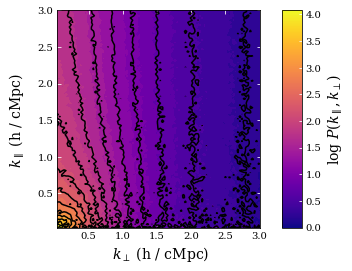

In [9]:
fig, axes = plt.subplots(1, 2, gridspec_kw = {'width_ratios':[1, .1]}, figsize = (4.4, 4), squeeze = False)
vlim = get_vlim(BIGK, vn)
cbar(axes[0, 1], vlim, CMAP)
cont(axes[0, 0], vn, vlim, BIGK)
clines(axes[0,0], vn, vlim)
lab_fig(fig, 4)
def_ticks(axes)

In [10]:
# functions for making the fits
from scipy.interpolate import interp1d
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')

def get_fit_func(k, pk1d, z, bias):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    pk_int = interp1d(k, pk1d, kind = 'linear', bounds_error = False, fill_value = 'extrapolate')
    def pk2d(k_vals, sigma_p):
        kpar, kper = k_vals
        k = np.sqrt(kpar**2 + kper**2)
        mu = kpar / k
        kaiser = (1 + f/bias * mu**2)**2 # according to equation 34 from VN18
        fog = (1 + 0.5 * kpar**2 * sigma_p**2)**-2
#         fog = np.exp(-0.5 * kpar**2 * sigma_p**2)
        pk = pk_int(k)
        return kaiser * pk * fog
    return pk2d


In [11]:
from scipy.optimize import curve_fit

kmax = 5
kpar, kper, pk2d = vn.getValues()
# mask = (kpar > kmax) & (kper > kmax)
mask = (kmax > np.sqrt(kpar**2 + kper**2))
n = np.sum(mask)
# print(kpar.shape)
# print(np.sum(mask))
vn1d = get_1Dpk(box, snap, 'vn')
k, pk, _ = vn1d.getValues()
model_func = get_fit_func(k, pk, 0.0, 0.77)
# uncert = np.sqrt(2 / vn.Nmodes[mask]) * pk2d[mask] trying with sigma values result in really poor fits
popt, pcov = curve_fit(model_func, (kpar[mask], kper[mask]), pk2d[mask], p0 = [1.7], bounds = [0,5])
popt, pcov

(array([2.36446189]), array([[0.00098844]]))

[]

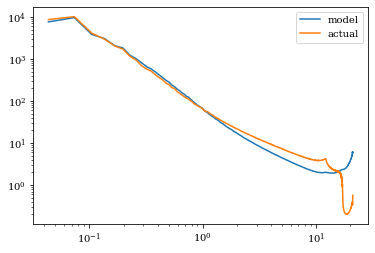

In [12]:
from scipy.integrate import quad

def integrand(mu, k, real_pk, f, bias, sigma):
    kaiser = real_pk * (1 + f / bias * mu**2)**2
    fog = (1.0 + 0.5*k**2 * mu**2 * sigma**2)**-2
    return kaiser * fog

def solve_integral(k, real_pk, z, bias, sigma):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrand, lower_limit, upper_limit, args=(k, real_pk, f, bias, sigma))
    
    return 0.5 * result  # Multiply the result by 0.5 as per the integral
rss = get_1Dpk(box, snap, 'vn', space = 'redshift')
rsk, rsspk, _ = rss.getValues()
rss_model = np.zeros_like(rsspk)
for i in range(len(rsk)):
    rss_model[i] = solve_integral(rsk[i], pk[i], 0, 0.77, popt[0])
plt.plot(rsk, rss_model, label = 'model')
plt.plot(rsk, rsspk, label = 'actual')
plt.legend()
plt.loglog()

In [13]:
print(np.unique(kpar).shape, np.unique(kper).shape)

(401,) (566,)


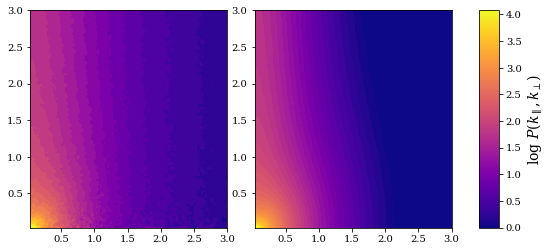

In [14]:
modelpk = model_func((kpar, kper), popt[0])
fig, axes = plt.subplots(1, 3, gridspec_kw = {'width_ratios':[1, 1, .1]}, figsize = (8.4, 4), squeeze = False)
vlim = get_vlim(BIGK, vn)
cbar(axes[0, 2], vlim, CMAP)
cont(axes[0, 0], vn, vlim, BIGK)
cont(axes[0, 1], (kpar, kper, modelpk), vlim, BIGK)

In [15]:
import scipy.stats

ALPHA = 0.05
def calc_ci(pcov, ndata):
    dof = ndata - len(pcov)
    t_mult = np.abs(np.sqrt(pcov.diagonal()) * scipy.stats.t.ppf(1 - ALPHA, dof))
    return t_mult


99 ptl 1.0 0
99 vn 0.77 0
99 hiptl 0.77 0
99 hisubhalo 0.77 0
67 ptl 1.0 0.5
67 vn 1.02 0.5
67 hiptl 1.02 0.5
67 hisubhalo 1.02 0.5
50 ptl 1.0 1
50 vn 1.3 1
50 hiptl 1.3 1
50 hisubhalo 1.3 1


Text(0, 0.5, '$k_\\perp$ (h / cMpc)')

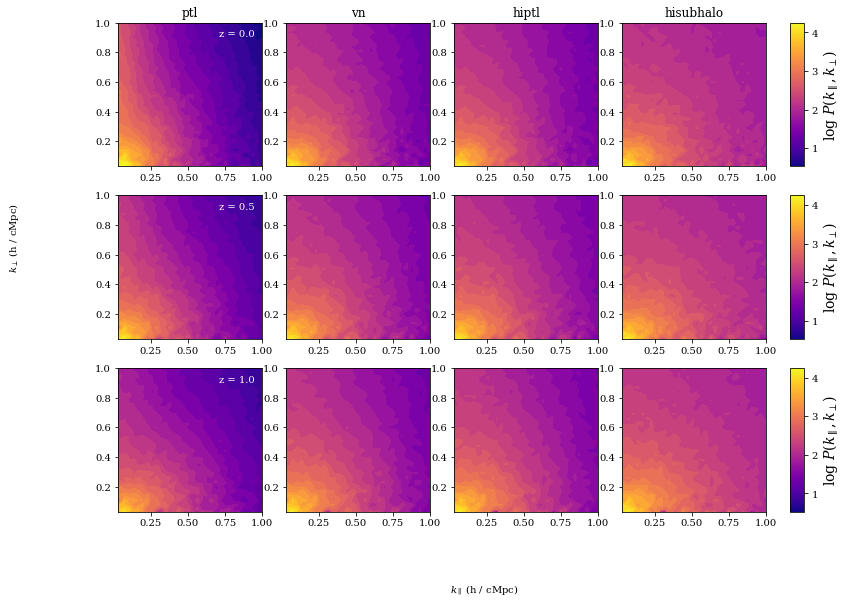

In [16]:
from scipy.optimize import curve_fit

# fieldnames = ['vn']
fieldnames = ['ptl', 'vn', 'hiptl', 'hisubhalo']
box = 300
snapshots = [99, 67, 50]
redshifts = [0, 0.5, 1]
biases = np.ones((len(snapshots), len(fieldnames)))
biases[0, 1:] = 0.77
biases[1, 1:] = 1.01
biases[2, 1:] = 1.29
bias_dict = {'vn':biases[:, 1], 'ptl':biases[:, 0]}
addtl_attr = [{'ptl_species':'ptl'}, {}, {'model':'GD14'}, {'model':'m_hi_GD14_map'}]
fig, axes = plt.subplots(len(snapshots), len(fieldnames) + 1,
                gridspec_kw = {'width_ratios':[1] * len(fieldnames) + [0.1]},
                figsize = (len(fieldnames) * 3 + 0.3, len(snapshots) * 3))
sigma_vals = np.zeros((len(snapshots), len(fieldnames)))
cis = np.zeros_like(sigma_vals)
kmax = 1
vlim = None
for i in range(len(snapshots)):
    
    for j in range(len(fieldnames)):
        print(snapshots[i], fieldnames[j], biases[i, j], redshifts[i])
        rc2d = get_2dpk(box, snapshots[i], fieldnames[j], **addtl_attr[j])
        rc1d = get_1Dpk(box, snapshots[i], fieldnames[j], **addtl_attr[j])
        kpar, kper, pk2d = rc2d.getValues()
        mask = (kpar < kmax) & (kper < kmax)
        k, pk, _ = rc1d.getValues()
        model_func = get_fit_func(k, pk, redshifts[i], biases[i, j])

        popt, pcov = curve_fit(model_func, (kpar[mask], kper[mask]), pk2d[mask], p0 = [2])
        sigma_vals[i, j] = popt[0]
        res = pk2d[mask] - model_func((kpar[mask], kper[mask]), popt[0])
        cis[i, j] = calc_ci(pcov, np.sum(mask))
        if vlim is None:
            vlim = get_vlim(ZOOMK, rc2d)
        
        cont(axes[i, j], rc2d, vlim, ZOOMK)
        if i == 0:
            axes[i, j].set_title(fieldnames[j])
        if j == 0:
            axes[i, j].text(0.95, 0.95, 'z = %.1f'%redshifts[i], transform = axes[i,j].transAxes,
                        va = 'top', ha = 'right', color = 'white')

    cbar(axes[i, len(fieldnames)], vlim, CMAP)
fig.text(0.5, 0, '$k_\parallel$ (h / cMpc)')
fig.text(0, 0.5, '$k_\perp$ (h / cMpc)', rotation = 'vertical')

In [17]:
print(sigma_vals, cis)
ptl_sigma = sigma_vals[:, 0]; ptl_cis = cis[:, 0]
vn_sigma = sigma_vals[:, 1]; vn_cis = cis[:, 0]

[[4.02736552 2.3959775  2.33893836 1.97535619]
 [3.74908903 3.06341938 3.08350007 2.73838409]
 [2.92024047 2.66264012 2.74543461 2.23350905]] [[0.2705935  0.23560986 0.23028799 0.20909581]
 [0.23562502 0.20160852 0.19754108 0.19118458]
 [0.22065362 0.20167443 0.19638223 0.17969302]]


{'vn': array([0.77, 1.02, 1.3 ]), 'ptl': array([1., 1., 1.]), 'resolved': array([1.46, 1.71, 2.04]), 'red': array([1.66, 2.1 , 2.61]), 'blue': array([0.93, 1.31, 1.73])}
99 resolved 1.46 0
99 red 1.66 0
99 blue 0.93 0
67 resolved 1.71 0.5
67 red 2.1 0.5
67 blue 1.31 0.5
50 resolved 2.04 1
50 red 2.61 1
50 blue 1.73 1


Text(0, 0.5, '$k_\\perp$ (h / cMpc)')

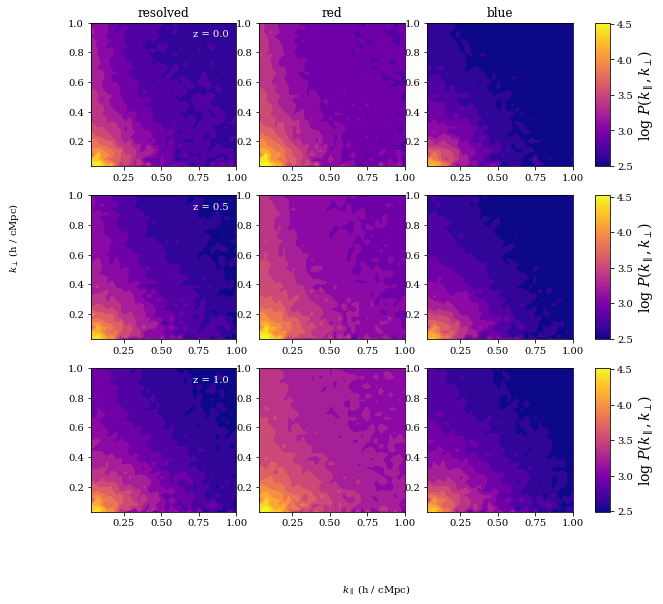

In [18]:
from scipy.optimize import curve_fit

# fieldnames = ['vn']
fieldnames = ['resolved', 'red', 'blue']
box = 300
snapshots = [99, 67, 50]
redshifts = [0, 0.5, 1]
biases = np.ones((len(snapshots), len(fieldnames)))
biases[:, 0] = [1.47, 1.71, 2.04]
biases[:, 1] = [1.66, 2.1, 2.61]
biases[:, 2] = [0.93, 1.31, 1.73]
galbias = {fieldnames[i] : biases[:, i] for i in range(len(fieldnames))}
bias_dict.update(galbias)
print(bias_dict)
addtl_attr = [{}, {}, {}]
fig, axes = plt.subplots(len(snapshots), len(fieldnames) + 1,
                gridspec_kw = {'width_ratios':[1] * len(fieldnames) + [0.1]},
                figsize = (len(fieldnames) * 3 + 0.3, len(snapshots) * 3))
sigma_vals = np.zeros((len(snapshots), len(fieldnames)))
cis = np.zeros_like(sigma_vals)
kmax = 1
vlim = None
for i in range(len(snapshots)):
    
    for j in range(len(fieldnames)):
        print(snapshots[i], fieldnames[j], biases[i, j], redshifts[i])
        rc2d = get_2dpk(box, snapshots[i], 'galaxy', color = fieldnames[j], **addtl_attr[j])
        rc1d = get_1Dpk(box, snapshots[i], 'galaxy', color = fieldnames[j], **addtl_attr[j])
        kpar, kper, pk2d = rc2d.getValues()
        mask = (kpar < kmax) & (kper < kmax)
        k, pk, _ = rc1d.getValues()
        model_func = get_fit_func(k, pk, redshifts[i], biases[i, j])

        popt, pcov = curve_fit(model_func, (kpar[mask], kper[mask]), pk2d[mask], p0 = [1])
        sigma_vals[i, j] = popt[0]
        cis[i, j] = calc_ci(pcov, np.sum(mask))
        
        if vlim is None:
            vlim = get_vlim(ZOOMK, rc2d)
        
        cont(axes[i, j], rc2d, vlim, ZOOMK)
        if i == 0:
            axes[i, j].set_title(fieldnames[j])
        if j == 0:
            axes[i, j].text(0.95, 0.95, 'z = %.1f'%redshifts[i], transform = axes[i,j].transAxes,
                        va = 'top', ha = 'right', color = 'white')

    cbar(axes[i, len(fieldnames)], vlim, CMAP)
fig.text(0.5, 0, '$k_\parallel$ (h / cMpc)')
fig.text(0, 0.5, '$k_\perp$ (h / cMpc)', rotation = 'vertical')

In [19]:
print(sigma_vals, cis)
sigmap = {fieldnames[i] : sigma_vals[:, i] for i in range(len(fieldnames))}
cisp = {fieldnames[i] : cis[:, i] for i in range(len(fieldnames))}
sigmap['vn'] = vn_sigma
sigmap['ptl'] = ptl_sigma
cisp['vn'] = vn_sigma
cisp['ptl'] = ptl_sigma


[[3.42084054 3.51972376 2.30253197]
 [2.97026767 2.81582881 2.85355446]
 [2.22079347 1.96592786 2.08785623]] [[0.18792037 0.18124628 0.16313915]
 [0.17436666 0.14666034 0.16812167]
 [0.14544517 0.08809336 0.1536885 ]]


# Making figures for paper

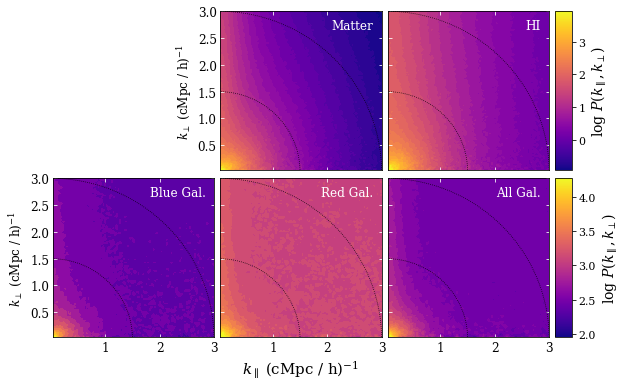

In [20]:
row1 = ['ptl', 'vn']
row2 = ['blue', 'red', 'resolved']
box = 300
snapshots = [50]
smooth_sigma = 0.5
redshifts = [1]
k_type = 'big'
if k_type == 'big':
    kaxlim = BIGK
else:
    kaxlim = ZOOMK
nlevels = 20
addtl_attr1 = [{'ptl_species':'ptl'}, {}]
# fig = plt.figure(figsize = (3 * 3 + 0.3, 2 * 3))
fig, axes = plt.subplots(2, 4,
                gridspec_kw = {'width_ratios':[1] * 3 + [0.1], 'wspace':0.05, 'hspace':0.05},
                figsize = (3 * 3 + 0.3, 2 * 3))

kmax = 1
vlim = None
titles = {'vn':'HI', 'ptl':'Matter', 'red':'Red Gal.', 'blue':'Blue Gal.', 'resolved':'All Gal.'}
for i in range(2):
    rc2d = get_2dpk(box, snapshots[0], row1[i], **addtl_attr1[i])
    kpar, kper, pk2d = rc2d.getValues()
    if vlim is None:
        vlim = get_vlim(kaxlim, rc2d)
    cont(axes[0, i + 1], rc2d, vlim, kaxlim)
    circles(axes[0, i + 1], rc2d, kaxlim, nlevels)
    axes[0, i + 1].text(0.95, 0.95, titles[row1[i]], fontsize = 12, color = 'white', ha = 'right', va ='top', transform = axes[0, i + 1].transAxes)

    axes[0, i + 1].tick_params(which = 'both', labelbottom = False, direction = 'in', color = 'white', top = True, right = True, labelsize = 12)
    if i == 0:
        axes[0, i+1].set_ylabel('$k_\perp$ (cMpc / h)$^{-1}$', fontsize = 12)
    else:
        axes[0, i + 1].tick_params(which = 'both', labelleft = False)
    
    

axes[0, 0].set_visible(False)
axes[0, 3].tick_params(labelsize = 11)
cbar(axes[0, 3], vlim, CMAP)    
vlim = None

for i in range(3):
    rc2d = get_2dpk(box, snapshots[0], 'galaxy', color = row2[i])
    kpar, kper, pk2d = rc2d.getValues()
    if vlim is None:
        vlim = get_vlim(kaxlim, rc2d)
    cont(axes[1, i], rc2d, vlim, kaxlim, smooth_sigma)
    circles(axes[1, i], rc2d, kaxlim, nlevels)

    axes[1, i].text(0.95, 0.95, titles[row2[i]], fontsize = 12, color = 'white', ha = 'right', va ='top', transform = axes[1, i].transAxes)
    axes[1, i].tick_params(which = 'both', direction = 'in', color = 'white', top = True, right = True, labelsize = 12)
    if i == 0:
        axes[1, i].set_ylabel('$k_\perp$ (cMpc / h)$^{-1}$', fontsize = 12)
    else:
        axes[1, i].tick_params(which = 'both', labelleft = False)

axes[1, 1].set_xlabel(r'$k_\parallel$ (cMpc / h)$^{-1}$', fontsize = 15)
axes[1, 3].tick_params(labelsize = 11)
cbar(axes[1, 3], vlim, CMAP)
plt.savefig('2Dpk_%d_%.1f_%s.pdf'%(snapshots[0],smooth_sigma, k_type), bbox_inches = 'tight', dpi = 200)

In [21]:
from scipy.integrate import quad

def integrand(mu, k, real_pk, f, bias, sigma):
    kaiser = real_pk * (1 + f / bias * mu**2)**2
    fog = (1.0 + 0.5*k**2 * mu**2 * sigma**2)**-2
    return kaiser * fog

def solve_integral(k, real_pk, z, bias, sigma):
    # Define the limits of integration
    lower_limit = -1.0
    upper_limit = 1.0
    
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    # Use quad from scipy to perform the numerical integration
    result, error = quad(integrand, lower_limit, upper_limit, args=(k, real_pk, f, bias, sigma))
    
    return 0.5 * result  # Multiply the result by 0.5 as per the integral

addtl_props = {'vn':{}, 'ptl':{'ptl_species':'ptl'}}
snapshots = [99, 67, 50]
redshifts = [0, 0.5, 1]
model_rss_dict = {}
for i in range(3):
    for fn in ['vn', 'ptl']:
        if fn not in model_rss_dict:
            model_rss_dict[fn] = {}
        rrc = get_1Dpk(box, snapshots[i], fn, space = 'real', **addtl_props[fn])
        rk, rpk, _ = rrc.getValues()
        rss_model = np.zeros((rpk.shape[0], 3))
        sigma = sigmap[fn][i]
        ci = cisp[fn][i]
        bias = bias_dict[fn][i]
        for j in range(len(rk)):
            rss_model[j, 0] = solve_integral(rk[j], rpk[j], redshifts[i], bias, sigma)
            rss_model[j, 1] = solve_integral(rk[j], rpk[j], redshifts[i], bias, sigma - ci)
            rss_model[j, 2] = solve_integral(rk[j], rpk[j], redshifts[i], bias, sigma + ci)
        model_rss_dict[fn][snapshots[i]] = rss_model
        
    for col in ['blue', 'red', 'resolved']:
        if col not in model_rss_dict:
            model_rss_dict[col] = {}
        rrc = get_1Dpk(box, snapshots[i], 'galaxy', color = col, space = 'real')
        rk, rpk, _ = rrc.getValues()
        rss_model = np.zeros((rpk.shape[0], 3))
        sigma = sigmap[col][i]
        ci = cisp[col][i]
        bias = bias_dict[col][i]
        for j in range(len(rk)):
            rss_model[j, 0] = solve_integral(rk[j], rpk[j], redshifts[i], bias, sigma)
            rss_model[j, 1] = solve_integral(rk[j], rpk[j], redshifts[i], bias, sigma - ci)
            rss_model[j, 2] = solve_integral(rk[j], rpk[j], redshifts[i], bias, sigma + ci)
        model_rss_dict[col][snapshots[i]] = rss_model

(10, 30000.0)

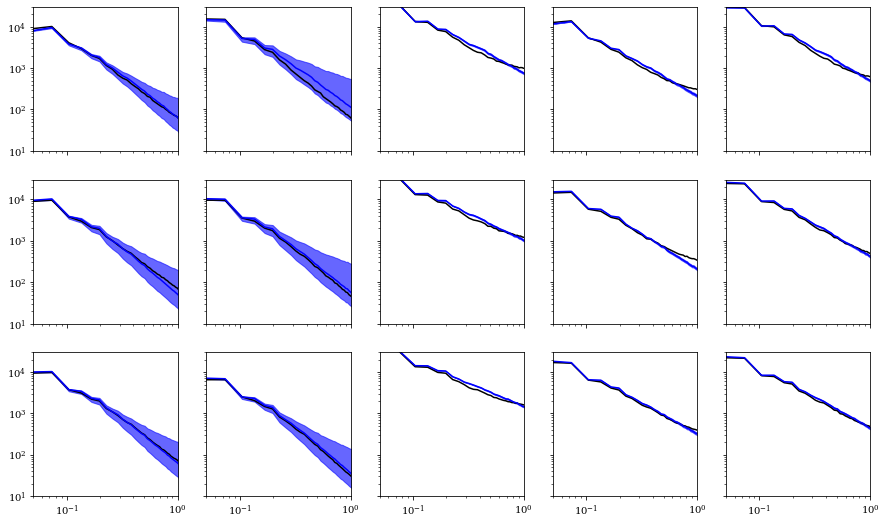

In [22]:
# big plot comparing actual and model values

fig, axes = plt.subplots(3, 5, figsize = (15, 9), sharex = True, sharey = True)
row_idx = 0
for snap in snapshots:
    
    col_idx = 0
    for fn in ['vn', 'ptl', 'red', 'blue', 'resolved']:
        
        if fn == 'vn' or fn == 'ptl':
            src = get_1Dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
        else:
            src = get_1Dpk(box, snap, 'galaxy', space = 'redshift', color = fn)
            
        sk, spk, _ = src.getValues()
        modelpk = model_rss_dict[fn][snap]
        plt.sca(axes[row_idx, col_idx])
        plt.loglog()
        plt.plot(sk, spk, label = 'actual', color = 'black')
        plt.plot(sk, modelpk[:, 0], label = 'model', color = 'blue')
        plt.fill_between(sk, modelpk[:, 1], modelpk[:, 2], alpha = 0.6, color = 'blue')
        col_idx += 1
    row_idx += 1
plt.xlim(0.05, 1)
plt.ylim(10, 3e4)

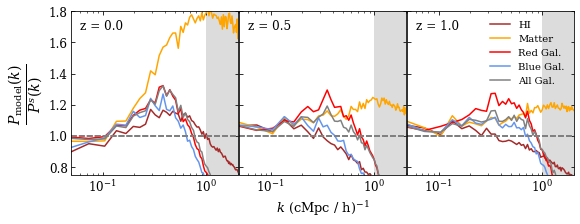

In [23]:
# fraction at each snapshot
with_err = False
with_m = True
extend_x = True
fig, axes = plt.subplots(1, 3, figsize = (9, 3), sharex = True, sharey = True, gridspec_kw = {'wspace':0.01})
plt_kw = {}
plt_kw['vn'] = {'label':'HI', 'color':'brown'}
plt_kw['blue'] = {'label':'Blue Gal.', 'color':'cornflowerblue'}
plt_kw['red'] = {'label':'Red Gal.', 'color':'red'}
plt_kw['resolved'] = {'label':'All Gal.', 'color':'gray'}
plt_kw['ptl'] = {'label':'Matter', 'color':'orange'}
col_idx = 0
for snap in snapshots:
    
    
    for fn in ['vn', 'ptl', 'red', 'blue', 'resolved']:
        if fn == 'ptl' and not with_m:
            continue
        if fn == 'vn' or fn == 'ptl':
            src = get_1Dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
        else:
            src = get_1Dpk(box, snap, 'galaxy', space = 'redshift', color = fn)
            
        sk, spk, _ = src.getValues()
        modelpk = model_rss_dict[fn][snap]
        plt.sca(axes[col_idx])
        axes[col_idx].tick_params(which = 'both', top = True, right = True, direction = 'in', labelsize = 12)
        plt.xscale('log')
        plt.plot(sk, modelpk[:, 0]/spk, **plt_kw[fn])
        if with_err:
            plt.fill_between(sk, modelpk[:, 1]/spk, modelpk[:, 2]/spk, alpha = 0.6, color = plt_kw[fn]['color'])
        if extend_x:
            plt.fill_betweenx((0, 2), 1, 2, color = 'gainsboro')
        plt.plot((0.05, 2), (1, 1), linestyle = 'dashed', color = 'gray')
    axes[col_idx].text(0.05, 0.95, 'z = %.1f'%redshifts[col_idx], fontsize = 12, ha = 'left', va = 'top', transform = axes[col_idx].transAxes)
    col_idx += 1
if extend_x:
    plt.xlim(0.05, 2)
else:
    plt.xlim(0.05, 1)
plt.ylim(0.75, 1.8)
plt.legend(loc = 'upper right', frameon = False)
axes[1].set_xlabel('$k$ (cMpc / h)$^{-1}$', fontsize = 13)
axes[0].set_ylabel(r'$\frac{P_{\mathrm{model}} (k)}{P^s (k)}$', fontsize = 20)
suffix = ''
if with_m:
    suffix += 'with_m_'
else:
    suffix += 'no_m_'

if extend_x:
    suffix += 'x_extend'
else:
    suffix += 'x_short'
plt.savefig('modelerr_frac_snap_' + suffix + '.pdf', dpi = 200, bbox_inches = 'tight')

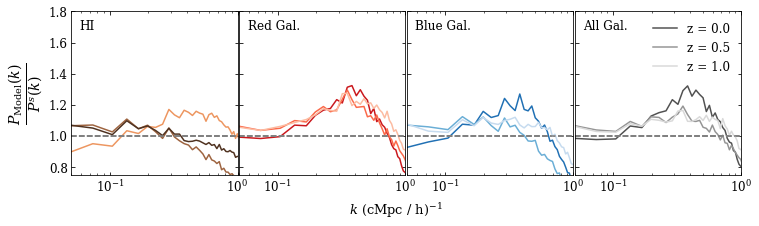

In [24]:
# compare snapshots
import seaborn as sbn
with_err = False
with_m = False
extend_x = False
if with_m:
    col = 5
    names = ['vn', 'ptl', 'red', 'blue', 'resolved']
else:
    col = 4
    names = ['vn', 'red', 'blue', 'resolved']
fig, axes = plt.subplots(1, col, figsize = (3*col, 3), sharex = True, sharey = True, gridspec_kw = {'wspace':0.01})
plt_kw = {}
plt_kw['vn'] = {'label':'HI', 'color':'copper'}
plt_kw['blue'] = {'label':'Blue Gal.', 'color':'Blues'}
plt_kw['red'] = {'label':'Red Gal.', 'color':'Reds'}
plt_kw['resolved'] = {'label':'All Gal.', 'color':'Greys'}
plt_kw['ptl'] = {'label':'Matter', 'color':'Greens'}
col_idx = 0
for fn in names:
    if fn == 'ptl' and not with_m:
        continue
    
    colors = sbn.color_palette(plt_kw[fn]['color'], 3)
    colors.reverse()
    color_idx = 0
    for snap in snapshots:
        
        if fn == 'vn' or fn == 'ptl':
            src = get_1Dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
        else:
            src = get_1Dpk(box, snap, 'galaxy', space = 'redshift', color = fn)
            
        sk, spk, _ = src.getValues()
        modelpk = model_rss_dict[fn][snap]
        plt.sca(axes[col_idx])
        axes[col_idx].tick_params(which = 'both', top = True, right = True, direction = 'in', labelsize = 12)
        plt.xscale('log')
        plt.plot(sk, modelpk[:, 0]/spk, label = 'z = %.1f'%redshifts[color_idx], color = colors[color_idx])
        plt.plot((0.05, 2), (1, 1), linestyle = 'dashed', color = 'gray')

        if with_err:
            plt.fill_between(sk, modelpk[:, 1]/spk, modelpk[:, 2]/spk, alpha = 0.6, color = colors[color_idx])
        if extend_x:
            plt.fill_betweenx((0, 2), 1, 2, color = 'gainsboro')
        color_idx+=1
    axes[col_idx].text(0.05, 0.95, plt_kw[fn]['label'], fontsize = 12, ha = 'left', va = 'top', transform = axes[col_idx].transAxes)

    col_idx += 1

if extend_x:
    plt.xlim(0.05, 2)
else:
    plt.xlim(0.05, 1)
plt.ylim(0.75, 1.8)
plt.legend(loc = 'upper right', frameon = False, fontsize = 12)
fig.text(0.5, -0.08, '$k$ (cMpc / h)$^{-1}$', fontsize = 13, ha = 'center', va = 'bottom')
axes[0].set_ylabel(r'$\frac{P_{\mathrm{Model}} (k)}{P^s (k)}$', fontsize = 20)
suffix = ''
if with_m:
    suffix += 'with_m_'
else:
    suffix += 'no_m_'

if extend_x:
    suffix += 'x_extend'
else:
    suffix += 'x_short'
plt.savefig('modelerr_frac_fn_' + suffix + '.pdf', dpi = 200, bbox_inches= 'tight')

# Calculate Chi-squared

(226966,)


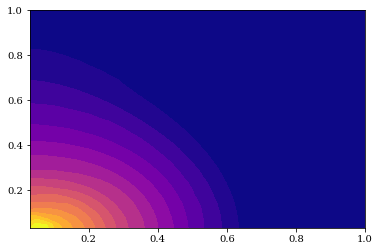

In [63]:
from scipy.stats import chisquare, chi2
def get_fit_func(k, pk1d, z, bias):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    pk_int = interp1d(k, pk1d, kind = 'linear', bounds_error = False, fill_value = 'extrapolate')
    def pk2d(k_vals, sigma_p):
        kpar, kper = k_vals
        k = np.sqrt(kpar**2 + kper**2)
        mu = kpar / k
        kaiser = (1 + f/bias * mu**2)**2 # according to equation 34 from VN18
        fog = (1 + 0.5 * kpar**2 * sigma_p**2)**-2
#         fog = np.exp(-0.5 * kpar**2 * sigma_p**2)
        pk = pk_int(k)
        return kaiser * pk * fog
    return pk2d



for i,snap in enumerate(snapshots):
    for fn in ['vn', 'ptl', 'red', 'blue', 'resolved']:

        if fn == 'vn' or fn == 'ptl':
            src = get_2dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
            src1d = get_1Dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
        else:
            src = get_2dpk(box, snap, 'galaxy', space = 'redshift', color = fn)
            src1d = get_1Dpk(box, snap, 'galaxy', space = 'redshift', color = fn)
        bias = bias_dict[fn][i]
        kpar, kper, pk2d = src.getValues()
        sk, spk, _ = src1d.getValues()
        model_func = get_fit_func(sk, spk, redshifts[i], bias)
        model2d = model_func((kpar, kper), sigma_p[fn][i])
        break
    break

    


            



In [73]:
def print_chi(klim):
    print("k <= %.1f"%klim)
    for i,snap in enumerate(snapshots):
        print(snap)
        for fn in ['vn', 'ptl', 'red', 'blue', 'resolved']:

            if fn == 'vn' or fn == 'ptl':
                src = get_1Dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
            else:
                src = get_1Dpk(box, snap, 'galaxy', space = 'redshift', color = fn)

            sk, spk, _ = src.getValues()
#             print(src.props)
            modelpk = model_rss_dict[fn][snap][:, 0]
            kmask = sk <= klim
            obs = spk[kmask]
            exp = modelpk[kmask]
            dof = np.sum(kmask) - 2
            chisq = np.sum((obs - exp)**2 / exp) / dof
            pval = 1 - chi2.cdf(chisq, dof)
            print("   ", fn, chisq, pval)
    return
for k in [1, 1.4, 10, 100]:
    print_chi(k)

k <= 1.0
99
    vn 9.745440611698308 0.9998273299071193
    ptl 54.810951043052036 0.0037289045478914318
    red 64.14127590690465 0.00028218082582265325
    blue 21.682980444635223 0.8653248893237222
    resolved 42.646985738572276 0.06292593360296328
67
    vn 7.731923639131465 0.9999864757480583
    ptl 9.559050239883282 0.9998592362426182
    red 63.45563854485169 0.00034449111740397775
    blue 30.574672923565 0.4365248571675092
    resolved 21.34475861062993 0.8767987559073971
50
    vn 4.297060908756261 0.9999999901244893
    ptl 5.86477509779142 0.9999994930028752
    red 81.3346177145589 1.2677741851874202e-06
    blue 14.471303721386295 0.9924028132536744
    resolved 17.94627703057735 0.9593970922947456
k <= 1.4
99
    vn 6.8906100938996975 0.9999999999439436
    ptl 42.83224529899072 0.4785163938075656
    red 109.45212858466199 1.0423339069642878e-07
    blue 42.72938194224812 0.48294568238232716
    resolved 59.8484782885939 0.04530242589799127
67
    vn 7.702473988755723

In [67]:
print_chi(ZOOMK)

99
	 vn 607952.6939799901 0.0
	 ptl 55014.66248644464 0.0
	 red 42343408009.9122 0.0
	 blue 1873616312.5451734 0.0
	 resolved 21309598464.952248 0.0
67
	 vn 1671107.3036509685 0.0
	 ptl 52933.212584155444 0.0
	 red 20069102287.082703 0.0
	 blue 4507695738.9337845 0.0
	 resolved 7991879615.440196 0.0
50
	 vn 743273.6508985084 0.0
	 ptl 19288.84206679806 0.0
	 red 6766580705.185026 0.0
	 blue 1404845851.8531246 0.0
	 resolved 2208401151.214171 0.0


In [ ]:
from scipy.stats import chisquare, chi2
def get_fit_func(k, pk1d, z, bias):
    D = cosmo.growthFactor(z, derivative = 0)
    dDdz = cosmo.growthFactor(z, derivative = 1)
    f = -dDdz * (z + 1) / D
    pk_int = interp1d(k, pk1d, kind = 'linear', bounds_error = False, fill_value = 'extrapolate')
    def pk2d(k_vals, sigma_p):
        kpar, kper = k_vals
        k = np.sqrt(kpar**2 + kper**2)
        mu = kpar / k
        kaiser = (1 + f/bias * mu**2)**2 # according to equation 34 from VN18
        fog = (1 + 0.5 * kpar**2 * sigma_p**2)**-2
#         fog = np.exp(-0.5 * kpar**2 * sigma_p**2)
        pk = pk_int(k)
        return kaiser * pk * fog
    return pk2d



for i,snap in enumerate(snapshots):
    for fn in ['vn', 'ptl', 'red', 'blue', 'resolved']:

        if fn == 'vn' or fn == 'ptl':
            src = get_2dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
            src1d = get_1Dpk(box, snap, fn, space = 'redshift', **addtl_props[fn])
        else:
            src = get_2dpk(box, snap, 'galaxy', space = 'redshift', color = fn)
            src1d = get_1Dpk(box, snap, 'galaxy', space = 'redshift', color = fn)
        bias = bias_dict[fn][i]
        kpar, kper, pk2d = src.getValues()
        sk, spk, _ = src1d.getValues()
        model_func = get_fit_func(sk, spk, redshifts[i], bias)
        model2d = model_func((kpar, kper), sigmap[fn][i])
        print(pk2d.shape)
        break
    break


ax = plt.gca()
cont(ax, (kpar, kper, model2d), vlim, ZOOMK)
